# Chicken GoGo Restaurant Operations Analysis

**Prepared as:** Data Analyst Intern business analysis project  
**Business context:** Quick-service restaurant operations  
**Main objective:** Turn raw restaurant files into clean tables, operational KPIs, charts, and clear recommendations that a manager can actually use.

This notebook follows a professional analyst workflow:

1. Define business questions and success metrics  
2. Build a file inventory and data dictionary  
3. Clean messy real-world restaurant spreadsheets  
4. Validate data quality before analysis  
5. Analyze sales, payment mix, tips, labor, schedules, menu pricing, purchasing, and startup expenses  
6. Connect findings to business decisions  
7. Export cleaned datasets for future reporting

> Note: The original Apple Numbers files were converted to `.xlsx` first. The converted files are stored in the `converted_xlsx/` folder.

In [1]:
# Core libraries
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = Path('converted_xlsx')
CHART_DIR = Path('charts')
CHART_DIR.mkdir(exist_ok=True)

files = sorted(DATA_DIR.glob('*.xlsx'))
file_inventory = pd.DataFrame({
    'file_name': [f.name for f in files],
    'size_kb': [round(f.stat().st_size / 1024, 1) for f in files]
})
file_inventory

,file_name,size_kb
0,6_12-6_15(4).xlsx,18.10
1,Chicken GoGo 材料采购清单(4).xlsx,15.60
2,Chicken Gogo 6_2-6_15 Payroll(4).xlsx,6.90
3,ChickenGoGO前(4).xlsx,14.70
4,Chicken_GoGo_menu.xlsx,5.90
5,Chicken_Gogo_schedule.xlsx,5.50
6,clock for6_1(4).xlsx,10.50
7,clock-7(4).xlsx,18.60
8,算账(4).xlsx,6.00
9,金世界价格产品表(3).xlsx,51.30


## Analyst Project Scope

A data analyst intern should not only make charts. The work should connect each dataset to a business decision. For this restaurant project, the main questions are:

| Business Area | Analyst Question | Useful Output |
|---|---|---|
| Sales | Which days are strongest or weakest? | Daily sales trend, average sales, best/worst day |
| Payments | How much revenue is card vs. cash? | Payment mix and card-share percentage |
| Tips | Are tips consistent with sales? | Tip rate by day |
| Labor | How many hours are being used by employee and day? | Time clock summary, daily labor hours |
| Labor Efficiency | How much sales are generated per labor hour? | Sales per labor hour table |
| Scheduling | Does schedule coverage match staffing needs? | Role coverage by day and time block |
| Menu | What are the visible menu price ranges? | Menu pricing table and price distribution |
| Purchasing | Which supplier appears cheapest by item? | Supplier lowest-price comparison |
| Startup Costs | What opening expenses are being tracked? | Cashflow and expense review |

This makes the notebook look more like a real intern deliverable because every section has a business purpose.

In [2]:
# Build a more detailed file inventory for the project
file_details = []
for f in files:
    try:
        xl = pd.ExcelFile(f)
        file_details.append({
            'file_name': f.name,
            'size_kb': round(f.stat().st_size / 1024, 1),
            'sheet_count': len(xl.sheet_names),
            'sheet_names': ', '.join(xl.sheet_names[:4])
        })
    except Exception as e:
        file_details.append({
            'file_name': f.name,
            'size_kb': round(f.stat().st_size / 1024, 1),
            'sheet_count': np.nan,
            'sheet_names': f'Could not read: {e}'
        })

file_inventory_detailed = pd.DataFrame(file_details)
file_inventory_detailed

,file_name,size_kb,sheet_count,sheet_names
0,6_12-6_15(4).xlsx,18.10,1,Sheet 1_clock-5
1,Chicken GoGo 材料采购清单(4).xlsx,15.60,2,"use everyweek_Table 1, china_Table 1"
2,Chicken Gogo 6_2-6_15 Payroll(4).xlsx,6.90,1,Sheet 1_Table 1
3,ChickenGoGO前(4).xlsx,14.70,3,"Chicken GoGo 前期_Tab, Chicken GoGo 前期_Tab_2, 开门流水"
4,Chicken_GoGo_menu.xlsx,5.90,1,工作表1
5,Chicken_Gogo_schedule.xlsx,5.50,1,工作表1
6,clock for6_1(4).xlsx,10.50,1,Sheet 1_clock
7,clock-7(4).xlsx,18.60,1,Sheet 1_clock-7
8,算账(4).xlsx,6.00,1,工作表1_T
9,金世界价格产品表(3).xlsx,51.30,1,TNG_Price_Level_Jacky


## Data Dictionary

This notebook creates cleaned tables with consistent English column names. This is important because real business spreadsheets often have mixed Chinese/English headers, blank rows, and layout-style formatting.

| Cleaned Table | Main Columns | Business Meaning |
|---|---|---|
| `sales` | `date`, `total_sales`, `credit_card`, `cash`, `tips`, `tip_rate` | Daily revenue and payment behavior |
| `clock` | `employee_name`, `clock_in_date`, `clock_out_date`, `elapsed_hours` | Actual hours worked from clock-in records |
| `payroll` | employee, total hours, tips, bonus | Payroll period summary |
| `schedule` | employee, role, day, start, end, hours | Planned staffing coverage |
| `menu_prices` | item/combo, price | Menu price information extracted from headers |
| `supplier_comparison` | item and supplier price columns | Purchasing comparison across vendors |
| `startup` / `opening_cashflow` | date, deposits, expenses, remaining balance | Startup and opening expense tracking |

## 1. Helper Functions

Restaurant spreadsheets are usually not perfectly structured. Some files have title rows, blank columns, Chinese headers, merged-cell style layouts, or multiple tables in one sheet. These helper functions make the cleaning process repeatable.

In [3]:
def read_raw_xlsx(path, sheet=0):
    """Read an Excel sheet without assuming the first row is the header."""
    return pd.read_excel(path, sheet_name=sheet, header=None)


def find_file(keyword):
    """Find one converted xlsx file using part of its name."""
    matches = [f for f in files if keyword.lower() in f.name.lower()]
    if not matches:
        raise FileNotFoundError(f'No file found containing: {keyword}')
    return matches[0]


def clean_currency_series(s):
    """Convert strings like $1,234.50 or Chinese/blank cells into numeric values."""
    return pd.to_numeric(
        s.astype(str)
         .str.replace('$', '', regex=False)
         .str.replace(',', '', regex=False)
         .str.replace('（未结）', '', regex=False)
         .str.replace('(未结)', '', regex=False)
         .str.extract(r'(-?\d+\.?\d*)')[0],
        errors='coerce'
    )


def safe_divide(a, b):
    return np.where(b == 0, np.nan, a / b)

## Data Quality Checklist

Before trusting the results, an analyst should check for missing files, unreadable sheets, duplicate records, missing dates, and impossible numeric values. The checks below are not just for coding; they protect the business from making decisions from messy data.

In [4]:
# Basic project-level data quality checks
quality_checks = pd.DataFrame({
    'Check': [
        'Converted Excel files available',
        'At least one sales/accounting file found',
        'At least one time clock file found',
        'Menu file found',
        'Schedule file found'
    ],
    'Result': [
        len(files) > 0,
        any('算账' in f.name for f in files),
        any('clock' in f.name.lower() for f in files),
        any('menu' in f.name.lower() for f in files),
        any('schedule' in f.name.lower() for f in files)
    ]
})
quality_checks

,Check,Result
0,Converted Excel files available,True
1,At least one sales/accounting file found,True
2,At least one time clock file found,True
3,Menu file found,True
4,Schedule file found,True


## 2. Sales / Accounting Analysis

This section uses the daily accounting file (`算账`) to answer questions like:

- How much revenue did the restaurant make each day?
- What percentage of sales came from credit card vs. cash?
- Which days had the highest tips?
- What is the tip rate compared with total revenue?

In [5]:
# Load daily sales file
sales_path = find_file('算账')
sales_raw = read_raw_xlsx(sales_path)
display(sales_raw.head(10))

# Row 1 contains the real column names
sales = sales_raw.iloc[2:].copy()
sales.columns = ['date', 'total_sales', 'credit_card', 'cash', 'tips', 'company', 'expenses']
sales = sales.dropna(how='all')

for col in ['total_sales', 'credit_card', 'cash', 'tips', 'company', 'expenses']:
    sales[col] = pd.to_numeric(sales[col], errors='coerce')

sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
sales = sales.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
sales['weekday'] = sales['date'].dt.day_name()
sales['credit_card_share'] = sales['credit_card'] / sales['total_sales']
sales['cash_share'] = sales['cash'] / sales['total_sales']
sales['tip_rate'] = sales['tips'] / sales['total_sales']

sales

,0,1,2,3,4,5,6
0,6 月份,NaN,NaN,NaN,NaN,NaN,NaN
1,时间,营业额（Total）,信用卡,现金,小费,公司,支出
2,2026-06-09 00:00:00,"3,137.46","2,716.41",421.05,155.56,NaN,NaN
3,2026-06-10 00:00:00,"2,929.11","2,605.52",323.59,135.34,NaN,NaN
4,2026-06-11 00:00:00,"2,669.07","2,094.14",473.46,101.47,NaN,NaN
5,2026-06-12 00:00:00,"2,480.68","2,255.72",224.96,96.29,NaN,NaN
6,2026-06-13 00:00:00,"2,810.63","2,497.48",313.15,161.71,NaN,NaN
7,2026-06-14 00:00:00,"2,599.07","2,287.78",311.29,106.99,NaN,NaN
8,2026-06-15 00:00:00,"2,203.69","1,787.47",416.22,113.42,NaN,NaN


,date,total_sales,credit_card,cash,tips,company,expenses,weekday,credit_card_share,cash_share,tip_rate
0,2026-06-09,"3,137.46","2,716.41",421.05,155.56,NaN,NaN,Tuesday,0.87,0.13,0.05
1,2026-06-10,"2,929.11","2,605.52",323.59,135.34,NaN,NaN,Wednesday,0.89,0.11,0.05
2,2026-06-11,"2,669.07","2,094.14",473.46,101.47,NaN,NaN,Thursday,0.78,0.18,0.04
3,2026-06-12,"2,480.68","2,255.72",224.96,96.29,NaN,NaN,Friday,0.91,0.09,0.04
4,2026-06-13,"2,810.63","2,497.48",313.15,161.71,NaN,NaN,Saturday,0.89,0.11,0.06
5,2026-06-14,"2,599.07","2,287.78",311.29,106.99,NaN,NaN,Sunday,0.88,0.12,0.04
6,2026-06-15,"2,203.69","1,787.47",416.22,113.42,NaN,NaN,Monday,0.81,0.19,0.05


### Sales Data Validation

A good intern analysis should confirm whether the accounting numbers are internally consistent. For example, total sales should be close to credit card plus cash unless there are other payment methods or manual adjustments.

In [6]:
# Validate payment totals against total sales
sales['payment_total_check'] = sales['credit_card'].fillna(0) + sales['cash'].fillna(0)
sales['payment_difference'] = sales['total_sales'] - sales['payment_total_check']

sales_validation = pd.DataFrame({
    'Metric': [
        'Rows in cleaned sales table',
        'Missing dates',
        'Missing total sales values',
        'Days where card + cash differs from total sales by more than $1',
        'Largest absolute payment difference'
    ],
    'Value': [
        len(sales),
        sales['date'].isna().sum(),
        sales['total_sales'].isna().sum(),
        (sales['payment_difference'].abs() > 1).sum(),
        sales['payment_difference'].abs().max()
    ]
})

sales_validation

,Metric,Value
0,Rows in cleaned sales table,7.00
1,Missing dates,0.00
2,Missing total sales values,0.00
3,Days where card + cash differs from total sale...,1.00
4,Largest absolute payment difference,101.47


In [7]:
# Sales KPI summary
sales_kpis = pd.DataFrame({
    'Metric': [
        'Total sales', 'Average daily sales', 'Highest daily sales', 'Lowest daily sales',
        'Total credit card sales', 'Total cash sales', 'Total tips',
        'Average credit card share', 'Average cash share', 'Average tip rate'
    ],
    'Value': [
        sales['total_sales'].sum(),
        sales['total_sales'].mean(),
        sales['total_sales'].max(),
        sales['total_sales'].min(),
        sales['credit_card'].sum(),
        sales['cash'].sum(),
        sales['tips'].sum(),
        sales['credit_card_share'].mean(),
        sales['cash_share'].mean(),
        sales['tip_rate'].mean()
    ]
})

sales_kpis['Formatted Value'] = sales_kpis.apply(
    lambda r: f"${r['Value']:,.2f}" if 'share' not in r['Metric'].lower() and 'rate' not in r['Metric'].lower()
    else f"{r['Value']:.1%}",
    axis=1
)
sales_kpis[['Metric', 'Formatted Value']]

,Metric,Formatted Value
0,Total sales,"$18,829.71"
1,Average daily sales,"$2,689.96"
2,Highest daily sales,"$3,137.46"
3,Lowest daily sales,"$2,203.69"
4,Total credit card sales,"$16,244.52"
5,Total cash sales,"$2,483.72"
6,Total tips,$870.78
7,Average credit card share,86.1%
8,Average cash share,13.3%
9,Average tip rate,4.6%


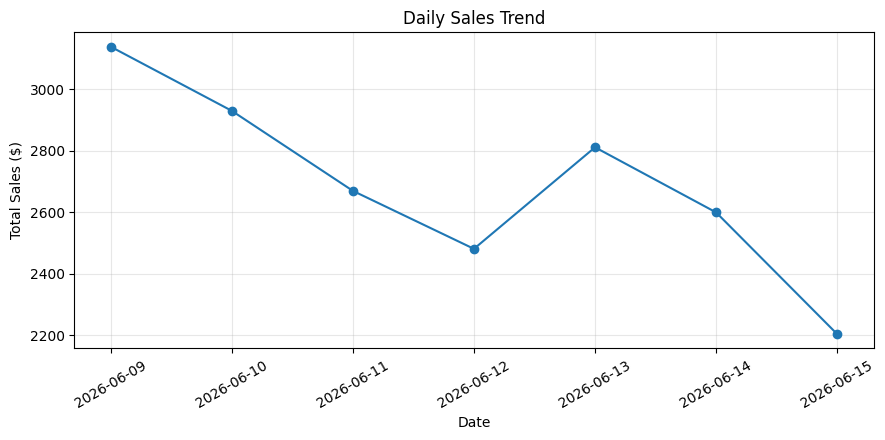

In [8]:
# Daily sales trend
plt.figure(figsize=(9, 4.5))
plt.plot(sales['date'], sales['total_sales'], marker='o')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR/'daily_sales_trend.png', dpi=150)
plt.show()

,Payment Method,Amount,Share
0,Credit Card,"16,244.52",0.87
1,Cash,"2,483.72",0.13


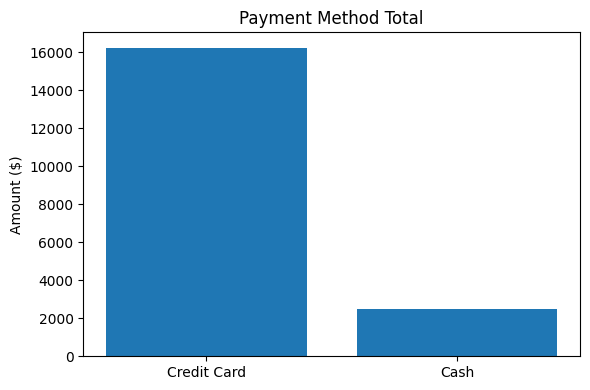

In [9]:
# Payment mix
payment_mix = pd.DataFrame({
    'Payment Method': ['Credit Card', 'Cash'],
    'Amount': [sales['credit_card'].sum(), sales['cash'].sum()]
})
payment_mix['Share'] = payment_mix['Amount'] / payment_mix['Amount'].sum()

display(payment_mix)

plt.figure(figsize=(6, 4))
plt.bar(payment_mix['Payment Method'], payment_mix['Amount'])
plt.title('Payment Method Total')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.savefig(CHART_DIR/'payment_method_total.png', dpi=150)
plt.show()

In [10]:
# Tip analysis
sales[['date', 'weekday', 'total_sales', 'tips', 'tip_rate']].sort_values('tip_rate', ascending=False)

,date,weekday,total_sales,tips,tip_rate
4,2026-06-13,Saturday,"2,810.63",161.71,0.06
6,2026-06-15,Monday,"2,203.69",113.42,0.05
0,2026-06-09,Tuesday,"3,137.46",155.56,0.05
1,2026-06-10,Wednesday,"2,929.11",135.34,0.05
5,2026-06-14,Sunday,"2,599.07",106.99,0.04
3,2026-06-12,Friday,"2,480.68",96.29,0.04
2,2026-06-11,Thursday,"2,669.07",101.47,0.04


### Sales Analyst Notes

These notes are written like a business analyst would explain them to a restaurant owner.

In [11]:
best_day = sales.loc[sales['total_sales'].idxmax()]
worst_day = sales.loc[sales['total_sales'].idxmin()]
card_share = sales['credit_card'].sum() / sales['total_sales'].sum()
cash_share = sales['cash'].sum() / sales['total_sales'].sum()

sales_notes = f"""
- Total sales in the file were **${sales['total_sales'].sum():,.2f}** across **{len(sales)} recorded business days**.
- Average daily sales were **${sales['total_sales'].mean():,.2f}**.
- The strongest day was **{best_day['date'].date()} ({best_day['weekday']})** with **${best_day['total_sales']:,.2f}** in sales.
- The slowest day was **{worst_day['date'].date()} ({worst_day['weekday']})** with **${worst_day['total_sales']:,.2f}** in sales.
- Credit card payments represented about **{card_share:.1%}** of total sales, while cash represented about **{cash_share:.1%}**.
- The average tip rate was **{sales['tip_rate'].mean():.1%}** of sales.
"""
display(Markdown(sales_notes))


- Total sales in the file were **$18,829.71** across **7 recorded business days**.
- Average daily sales were **$2,689.96**.
- The strongest day was **2026-06-09 (Tuesday)** with **$3,137.46** in sales.
- The slowest day was **2026-06-15 (Monday)** with **$2,203.69** in sales.
- Credit card payments represented about **86.3%** of total sales, while cash represented about **13.2%**.
- The average tip rate was **4.6%** of sales.


## 3. Time Clock / Labor Hours Analysis

This section combines the time clock exports and removes duplicates. The goal is to understand:

- Who worked the most hours?
- What days had the highest labor hours?
- Are clock-in / clock-out records clean?
- How can this support better scheduling?

In [12]:
# Load and clean time clock files
clock_keywords = ['clock for6_1', 'clock-7', '6_12-6_15']
clock_frames = []

for kw in clock_keywords:
    path = find_file(kw)
    raw = read_raw_xlsx(path)
    temp = raw.iloc[2:, :8].copy()
    temp.columns = ['employee_id', 'employee_name', 'employee_custom_id', 'clock_in_date', 'clock_in_time', 'clock_out_date', 'clock_out_time', 'elapsed_hours']
    temp['source_file'] = path.name
    clock_frames.append(temp)

clock = pd.concat(clock_frames, ignore_index=True)
clock = clock.dropna(subset=['employee_name', 'clock_in_date', 'clock_in_time'], how='any')
clock['elapsed_hours'] = pd.to_numeric(clock['elapsed_hours'], errors='coerce')
clock['clock_in'] = pd.to_datetime(clock['clock_in_date'].astype(str) + ' ' + clock['clock_in_time'].astype(str), errors='coerce')
clock['clock_out'] = pd.to_datetime(clock['clock_out_date'].astype(str) + ' ' + clock['clock_out_time'].astype(str), errors='coerce')
clock['work_date'] = clock['clock_in'].dt.date
clock['weekday'] = clock['clock_in'].dt.day_name()
clock['employee_name'] = clock['employee_name'].astype(str).str.strip()

# Remove duplicate rows across overlapping exports
clock = clock.drop_duplicates(subset=['employee_id', 'employee_name', 'clock_in', 'clock_out', 'elapsed_hours'])
clock = clock.sort_values(['clock_in', 'employee_name']).reset_index(drop=True)

clock.head(10)

/tmp/ipykernel_7275/2796062501.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clock['clock_out'] = pd.to_datetime(clock['clock_out_date'].astype(str) + ' ' + clock['clock_out_time'].astype(str), errors='coerce')


,employee_id,employee_name,employee_custom_id,clock_in_date,clock_in_time,clock_out_date,clock_out_time,elapsed_hours,source_file,clock_in,clock_out,work_date,weekday
0,E4H5AKA9V57EY,Chaolor,NaN,25-May-2026,11:00:38 AM,25-May-2026,02:07:16 PM,3.11,clock for6_1(4).xlsx,2026-05-25 11:00:38,2026-05-25 14:07:16,2026-05-25,Monday
1,C6X882GQ4C1V2,Justice Sternin,NaN,25-May-2026,11:01:02 AM,25-May-2026,02:06:19 PM,3.09,clock for6_1(4).xlsx,2026-05-25 11:01:02,2026-05-25 14:06:19,2026-05-25,Monday
2,R04QCY1QR7CSC,Jaxon Jimenez,NaN,25-May-2026,11:01:13 AM,25-May-2026,02:06:35 PM,3.09,clock for6_1(4).xlsx,2026-05-25 11:01:13,2026-05-25 14:06:35,2026-05-25,Monday
3,Z4307TXG1FFQT,Betty Ross,NaN,25-May-2026,02:07:36 PM,25-May-2026,04:49:34 PM,2.70,clock for6_1(4).xlsx,2026-05-25 14:07:36,2026-05-25 16:49:34,2026-05-25,Monday
4,P7KZATSSNZGSW,Kaylee Horak,NaN,25-May-2026,02:07:52 PM,25-May-2026,04:49:47 PM,2.70,clock for6_1(4).xlsx,2026-05-25 14:07:52,2026-05-25 16:49:47,2026-05-25,Monday
5,MB3CJE6WHGRD8,Andrew Yim,NaN,26-May-2026,04:03:04 PM,26-May-2026,07:11:42 PM,3.14,clock for6_1(4).xlsx,2026-05-26 16:03:04,2026-05-26 19:11:42,2026-05-26,Tuesday
6,DSVHBNWM39W1W,Alan Macias,NaN,26-May-2026,04:03:56 PM,26-May-2026,07:09:03 PM,3.09,clock for6_1(4).xlsx,2026-05-26 16:03:56,2026-05-26 19:09:03,2026-05-26,Tuesday
7,WW85HBBAJ040G,Julian palamidessi,NaN,26-May-2026,04:04:59 PM,26-May-2026,07:08:06 PM,3.05,clock for6_1(4).xlsx,2026-05-26 16:04:59,2026-05-26 19:08:06,2026-05-26,Tuesday
8,Q1MD7FSEPGNJY,Nevaeh Jordan,NaN,26-May-2026,04:05:41 PM,26-May-2026,07:08:19 PM,3.04,clock for6_1(4).xlsx,2026-05-26 16:05:41,2026-05-26 19:08:19,2026-05-26,Tuesday
9,1FSSAGN1X57C0,Finnegan,NaN,26-May-2026,04:06:19 PM,26-May-2026,07:08:46 PM,3.04,clock for6_1(4).xlsx,2026-05-26 16:06:19,2026-05-26 19:08:46,2026-05-26,Tuesday


In [13]:
clock_summary = (
    clock.groupby('employee_name', as_index=False)
    .agg(
        shifts=('elapsed_hours', 'count'),
        total_hours=('elapsed_hours', 'sum'),
        avg_shift_hours=('elapsed_hours', 'mean'),
        first_shift=('clock_in', 'min'),
        last_shift=('clock_in', 'max')
    )
    .sort_values('total_hours', ascending=False)
)
clock_summary.head(15)

,employee_name,shifts,total_hours,avg_shift_hours,first_shift,last_shift
4,Chaolor,16,41.02,2.56,2026-05-25 11:00:38,2026-05-28 10:56:26
18,Nevaeh Jordan,16,39.01,2.44,2026-05-26 16:05:41,2026-05-30 10:55:53
11,Guowei He,20,37.96,1.90,2026-05-27 10:58:19,2026-05-28 13:21:04
2,Andrew Yim,16,36.52,2.28,2026-05-26 16:03:04,2026-05-30 12:42:42
14,Julian palamidessi,16,35.77,2.24,2026-05-26 16:04:59,2026-05-30 12:37:14
12,Jaxon Jimenez,13,31.24,2.40,2026-05-25 11:01:13,2026-05-25 11:01:13
10,Finnegan,12,27.35,2.28,2026-05-26 16:06:19,2026-05-30 17:01:47
19,Sophia Rybin,10,23.43,2.34,2026-05-27 17:00:33,2026-05-27 17:00:33
0,Alan Macias,9,22.18,2.46,2026-05-26 16:03:56,2026-05-26 16:03:56
16,Kaylee Horak,9,21.78,2.42,2026-05-25 14:07:52,2026-05-27 17:01:31


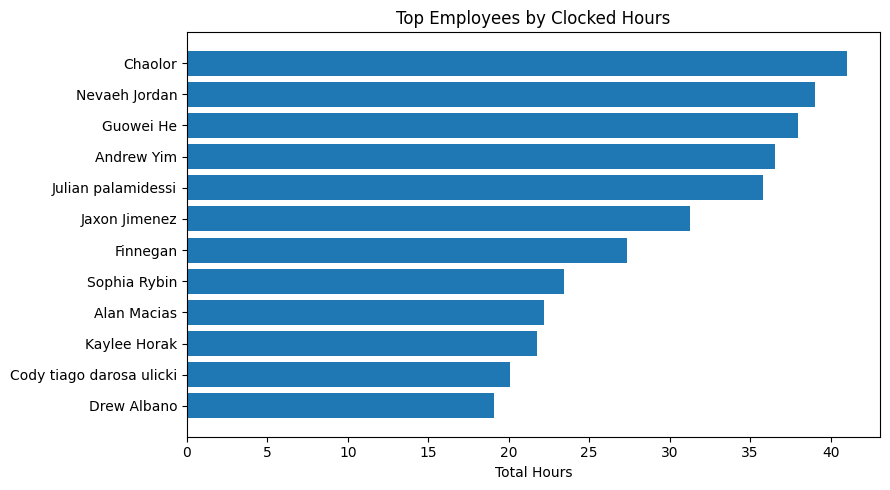

In [14]:
plt.figure(figsize=(9, 5))
top_hours = clock_summary.head(12).sort_values('total_hours')
plt.barh(top_hours['employee_name'], top_hours['total_hours'])
plt.title('Top Employees by Clocked Hours')
plt.xlabel('Total Hours')
plt.tight_layout()
plt.savefig(CHART_DIR/'employee_total_hours.png', dpi=150)
plt.show()

,work_date,weekday,total_labor_hours,shifts
0,2026-05-25,Monday,14.69,5
1,2026-05-26,Tuesday,23.81,8
2,2026-05-27,Wednesday,11.77,4
3,2026-05-28,Thursday,6.51,3
4,2026-05-30,Saturday,22.62,12


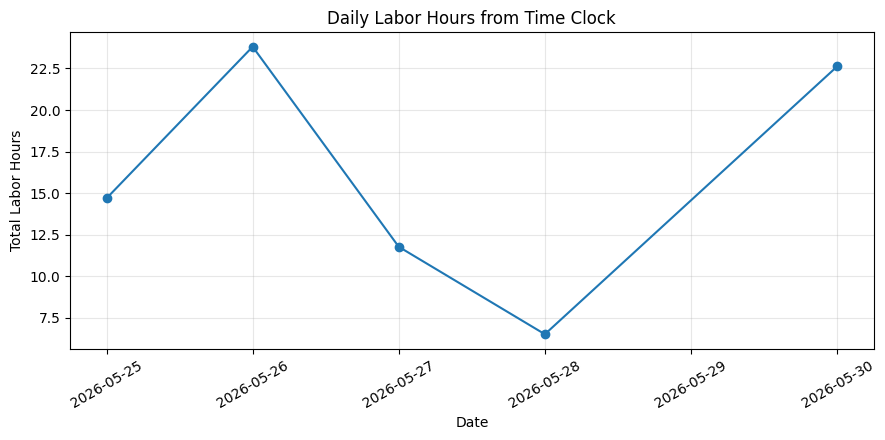

In [15]:
daily_labor = (
    clock.groupby(['work_date', 'weekday'], as_index=False)
    .agg(total_labor_hours=('elapsed_hours', 'sum'), shifts=('elapsed_hours', 'count'))
    .sort_values('work_date')
)

display(daily_labor)

plt.figure(figsize=(9, 4.5))
plt.plot(pd.to_datetime(daily_labor['work_date']), daily_labor['total_labor_hours'], marker='o')
plt.title('Daily Labor Hours from Time Clock')
plt.xlabel('Date')
plt.ylabel('Total Labor Hours')
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR/'daily_labor_hours.png', dpi=150)
plt.show()

### Labor Efficiency: Sales per Labor Hour

This is the type of KPI a restaurant manager would care about. It connects revenue to staffing. Higher sales per labor hour usually means better labor efficiency, while very low values may mean overstaffing or slow business. This KPI should be interpreted carefully because training days and soft-opening days can look inefficient on purpose.

In [16]:
# Combine sales and labor by date to calculate sales per labor hour
sales_daily = sales[['date', 'total_sales']].copy()
clock_daily = daily_labor.rename(columns={'work_date': 'date', 'total_labor_hours': 'labor_hours'}).copy()
clock_daily['date'] = pd.to_datetime(clock_daily['date'], errors='coerce')

labor_efficiency = sales_daily.merge(clock_daily[['date', 'labor_hours', 'shifts']], on='date', how='left')
labor_efficiency['sales_per_labor_hour'] = labor_efficiency['total_sales'] / labor_efficiency['labor_hours']

labor_efficiency.sort_values('date')

,date,total_sales,labor_hours,shifts,sales_per_labor_hour
0,2026-06-09,"3,137.46",NaN,NaN,NaN
1,2026-06-10,"2,929.11",NaN,NaN,NaN
2,2026-06-11,"2,669.07",NaN,NaN,NaN
3,2026-06-12,"2,480.68",NaN,NaN,NaN
4,2026-06-13,"2,810.63",NaN,NaN,NaN
5,2026-06-14,"2,599.07",NaN,NaN,NaN
6,2026-06-15,"2,203.69",NaN,NaN,NaN


In [17]:
# Visualize labor efficiency when both sales and labor are available
plot_labor_eff = labor_efficiency.dropna(subset=['sales_per_labor_hour'])

if len(plot_labor_eff) > 0:
    plt.figure(figsize=(9, 4.5))
    plt.bar(plot_labor_eff['date'].dt.strftime('%Y-%m-%d'), plot_labor_eff['sales_per_labor_hour'])
    plt.title('Sales per Labor Hour')
    plt.xlabel('Date')
    plt.ylabel('Sales per Labor Hour ($)')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(CHART_DIR/'sales_per_labor_hour.png', dpi=150)
    plt.show()
else:
    display(Markdown('No overlapping dates between the sales file and time clock file, so sales per labor hour cannot be calculated yet.'))

No overlapping dates between the sales file and time clock file, so sales per labor hour cannot be calculated yet.

## 4. Payroll / Tips Analysis

This section uses the payroll file for June 2–June 15. It checks total hours and tips by employee.

In [18]:
payroll_path = find_file('Payroll')
payroll_raw = read_raw_xlsx(payroll_path)
display(payroll_raw.head())

payroll = payroll_raw.copy()
payroll.columns = ['employee_name', 'total_hours', 'tips', 'bonus']
payroll = payroll.dropna(subset=['employee_name'])
payroll['employee_name'] = payroll['employee_name'].astype(str).str.strip()
payroll['total_hours'] = pd.to_numeric(payroll['total_hours'], errors='coerce')
payroll['tips'] = pd.to_numeric(payroll['tips'], errors='coerce')
payroll['bonus'] = pd.to_numeric(payroll['bonus'], errors='coerce')
payroll['tip_per_hour'] = payroll['tips'] / payroll['total_hours']
payroll = payroll.sort_values('total_hours', ascending=False)
payroll.head(15)

,0,1,2,3
0,6/2-6/15,Total Hours,Tips,Bonus
1,Chao Lor,36.18,72.36,NaN
2,Justice Miles Cooper Sternin,9.43,18.86,NaN
3,Jaxon Darrell Jimenez,30.81,61.62,NaN
4,Betty Ross,11.92,23.84,NaN


,employee_name,total_hours,tips,bonus,tip_per_hour
20,Lingwei Qiu (half month not hours),"2,500.00",NaN,150.00,NaN
21,Shiyi Teng (half month not hours),"2,400.00",NaN,NaN,NaN
1,Chao Lor,36.18,72.36,NaN,2.00
9,Nevaeh Marie Jordan,34.20,68.40,30.00,2.00
14,Guowei He,33.17,66.34,30.00,2.00
6,Andrew Gin-Wah Yim,31.93,63.86,NaN,2.00
8,Julian Salvador Palamidessi,30.99,61.98,NaN,2.00
3,Jaxon Darrell Jimenez,30.81,61.62,NaN,2.00
10,Finnegan Andrew Butler,22.85,45.70,NaN,2.00
15,Sophia Nikole Rybin,21.74,43.48,30.00,2.00


In [19]:
payroll_kpis = pd.DataFrame({
    'Metric': ['Total payroll hours', 'Total tips', 'Average tip per labor hour', 'Employees in payroll file'],
    'Value': [
        payroll['total_hours'].sum(),
        payroll['tips'].sum(),
        payroll['tips'].sum() / payroll['total_hours'].sum(),
        payroll['employee_name'].nunique()
    ]
})
payroll_kpis

,Metric,Value
0,Total payroll hours,"5,280.96"
1,Total tips,761.92
2,Average tip per labor hour,0.14
3,Employees in payroll file,22.00


### Payroll Data Quality and Control Checks

Payroll should be checked for missing hours, unusual tip amounts, and duplicate employee rows. These checks help catch spreadsheet errors before payment or reporting decisions are made.

In [20]:
payroll_quality = pd.DataFrame({
    'Check': [
        'Payroll rows',
        'Employees in payroll file',
        'Missing total hours',
        'Missing tips',
        'Duplicate employee rows'
    ],
    'Value': [
        len(payroll),
        payroll.iloc[:, 0].nunique() if len(payroll.columns) > 0 else np.nan,
        payroll.select_dtypes(include='number').isna().sum().sum(),
        payroll.astype(str).apply(lambda col: col.str.contains('nan', case=False, na=False)).sum().sum(),
        payroll.iloc[:, 0].duplicated().sum() if len(payroll.columns) > 0 else np.nan
    ]
})
payroll_quality

,Check,Value
0,Payroll rows,22
1,Employees in payroll file,22
2,Missing total hours,25
3,Missing tips,25
4,Duplicate employee rows,0


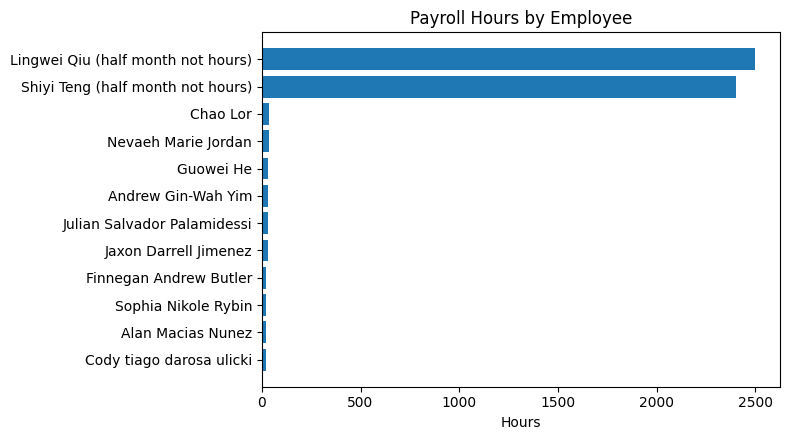

In [21]:
plt.figure(figsize=(8, 4.5))
plot_df = payroll.head(12).sort_values('total_hours')
plt.barh(plot_df['employee_name'], plot_df['total_hours'])
plt.title('Payroll Hours by Employee')
plt.xlabel('Hours')
plt.tight_layout()
plt.savefig(CHART_DIR/'payroll_hours_by_employee.png', dpi=150)
plt.show()

## 5. Schedule Coverage Analysis

The schedule file is less structured because each day is stored as a column with text entries like `Name(Role) 11-2`. This section extracts employee, role, start time, end time, and estimated shift length.

In [22]:
schedule_path = find_file('schedule')
schedule_raw = pd.read_excel(schedule_path, header=None)
schedule_raw.head(10)

,0,1,2,3
0,Monday 5/25,Tuesday 5/26,Wednesday 5/27,Thursday 5/28
1,Justice(Kitchen) 11-2,Emily(Cashier) 4-7,Kaylee(Cashier) 5-9 (10 mins),Guowei(Kitchen) 10:30-2:30 (10 mins)
2,Jaxon(Kitchen) 11-2,Finnegan(Cashier) 4-7,Betty (Cashier) 5-9 (10 mins),Chao(Kitchen) 10:30-2:30 (10 mins)
3,Chao(Kitchen)11-2,Mckenzie(Cashier) 4-7,Sophia (Cashier) 5-9 (10 mins),NaN
4,Kaylee(Cashier) 2-5,Julian(Kitchen) 4-7,Guowei(Kitchen) 11-2,NaN
5,Betty (Cashier) 2-5,Nevaen(Kitchen) 4-7,NaN,NaN
6,Sophia (Cashier) 2-5,Andrew(Kitchen) 4-7,NaN,NaN
7,NaN,Amarion(Kitchen) 5-7,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


In [23]:
def parse_shift(text, day_header):
    if pd.isna(text):
        return None
    text = str(text).strip()
    if not text or text.lower() == 'nan':
        return None
    # Extract day/date from header, e.g., Monday 5/25
    header = str(day_header)
    day_match = re.match(r'([A-Za-z]+)\s+(\d{1,2}/\d{1,2})', header)
    weekday = day_match.group(1) if day_match else header
    date_label = day_match.group(2) if day_match else None

    role_match = re.search(r'\(([^)]+)\)', text)
    role = role_match.group(1).strip() if role_match else 'Unknown'
    employee = re.sub(r'\([^)]*\)', '', text).strip()
    employee = re.split(r'\d', employee)[0].strip()

    # Extract time range such as 11-2, 4-7, 10:30-2:30
    time_match = re.search(r'(\d{1,2}(?::\d{2})?)\s*-\s*(\d{1,2}(?::\d{2})?)', text)
    if not time_match:
        return {'weekday': weekday, 'date_label': date_label, 'employee': employee, 'role': role, 'raw_shift': text}

    start, end = time_match.group(1), time_match.group(2)
    break_match = re.search(r'(\d+)\s*mins?', text.lower())
    break_minutes = int(break_match.group(1)) if break_match else 0

    def time_to_hours(t):
        if ':' in t:
            h, m = map(int, t.split(':'))
        else:
            h, m = int(t), 0
        return h + m / 60

    start_h = time_to_hours(start)
    end_h = time_to_hours(end)
    # Assume schedule is for daytime/evening restaurant shifts. If end <= start, push end to PM.
    if end_h <= start_h:
        end_h += 12
    # If start time looks like 10/11 and end is 2/3, this is morning-to-afternoon.
    if start_h >= 10 and end_h < 10:
        end_h += 12

    shift_hours = max(end_h - start_h - break_minutes / 60, 0)
    return {
        'weekday': weekday, 'date_label': date_label, 'employee': employee, 'role': role,
        'start_time': start, 'end_time': end, 'break_minutes': break_minutes,
        'scheduled_hours': shift_hours, 'raw_shift': text
    }

schedule_records = []
for col in schedule_raw.columns:
    day_header = schedule_raw.iloc[0, col]
    if pd.isna(day_header):
        continue
    for val in schedule_raw.iloc[1:, col]:
        parsed = parse_shift(val, day_header)
        if parsed:
            schedule_records.append(parsed)

schedule = pd.DataFrame(schedule_records)
schedule.head(20)

,weekday,date_label,employee,role,start_time,end_time,break_minutes,scheduled_hours,raw_shift
0,Monday,5/25,Justice,Kitchen,11,2,0.00,3.00,Justice(Kitchen) 11-2
1,Monday,5/25,Jaxon,Kitchen,11,2,0.00,3.00,Jaxon(Kitchen) 11-2
2,Monday,5/25,Chao,Kitchen,11,2,0.00,3.00,Chao(Kitchen)11-2
3,Monday,5/25,Kaylee,Cashier,2,5,0.00,3.00,Kaylee(Cashier) 2-5
4,Monday,5/25,Betty,Cashier,2,5,0.00,3.00,Betty (Cashier) 2-5
5,Monday,5/25,Sophia,Cashier,2,5,0.00,3.00,Sophia (Cashier) 2-5
6,Monday,5/25,Friday,Unknown,NaN,NaN,NaN,NaN,Friday 5/29
7,Tuesday,5/26,Emily,Cashier,4,7,0.00,3.00,Emily(Cashier) 4-7
8,Tuesday,5/26,Finnegan,Cashier,4,7,0.00,3.00,Finnegan(Cashier) 4-7
9,Tuesday,5/26,Mckenzie,Cashier,4,7,0.00,3.00,Mckenzie(Cashier) 4-7


In [24]:
schedule_role_summary = (
    schedule.groupby(['weekday', 'role'], as_index=False)
    .agg(scheduled_hours=('scheduled_hours', 'sum'), shifts=('raw_shift', 'count'))
    .sort_values(['weekday', 'role'])
)
display(schedule_role_summary)

schedule_employee_summary = (
    schedule.groupby(['employee', 'role'], as_index=False)
    .agg(shifts=('raw_shift', 'count'), scheduled_hours=('scheduled_hours', 'sum'))
    .sort_values('scheduled_hours', ascending=False)
)
schedule_employee_summary.head(20)

,weekday,role,scheduled_hours,shifts
0,Monday,Cashier,9.00,3
1,Monday,Kitchen,9.00,3
2,Monday,Unknown,0.00,1
3,Thursday,Kitchen,7.67,2
4,Tuesday,Cashier,20.50,6
5,Tuesday,Kitchen,20.67,7
6,Tuesday,Unknown,0.00,1
7,Wednesday,Cashier,11.50,3
8,Wednesday,Kitchen,14.50,4
9,Wednesday,Unknown,0.00,1


,employee,role,shifts,scheduled_hours
3,Chao,Kitchen,2,6.83
2,Betty,Cashier,2,6.83
14,Nevaen,Kitchen,2,6.83
16,Sophia,Cashier,2,6.83
5,Emily,Cashier,2,6.83
6,Finnegan,Cashier,2,6.83
9,Jaxon,Kitchen,2,6.83
8,Guowei,Kitchen,2,6.83
11,Justice,Kitchen,2,6.83
10,Julian,Kitchen,2,6.83


In [25]:
# Role coverage by day
role_pivot = schedule_role_summary.pivot_table(index='weekday', columns='role', values='scheduled_hours', aggfunc='sum').fillna(0)
role_pivot

role,Cashier,Kitchen,Unknown
weekday,,,
Monday,9.00,9.00,0.00
Thursday,0.00,7.67,0.00
Tuesday,20.50,20.67,0.00
Wednesday,11.50,14.50,0.00


### Scheduling Analyst Notes

A restaurant schedule should balance customer service and kitchen production. A simple analyst rule is:

- Front/cashier coverage should be strongest when order volume is high.
- Kitchen coverage should not drop too low during lunch/dinner rush.
- Very short shifts can create more handoff problems, while overly long shifts may increase labor cost or fatigue.

## 6. Menu Pricing Analysis

The menu file is not a normal item-by-row table. The combo prices are included in the column headers, so this section extracts the combo names and prices from those headers.

In [26]:
menu_path = find_file('menu')
menu_raw = pd.read_excel(menu_path, header=None)
menu_raw.head(12)

,0,1,2,3,4
0,Kid Combo(8.59),#1 Combo(11.29),#2 Combo(18.69),Chicken Sandwich Combo(11.79),NaN
1,2 Chicken Tenders,3 Chicken tenders,6 Chicken tenders,2 Chicken tenders,NaN
2,1 Gogo Sauce,1 Gogo Sauce,2 Gogo Sauce,Gogo Sauce & Lettuce,NaN
3,Crinkle-Cut Fries,Crinkle-Cut Fries,Crinkle-Cut Fries,Crinkle-Cut Fries,NaN
4,Whole milk/apple juice,Texas Toast,Texas Toast&Coleslaw,On a Toast Bun,NaN
5,NaN,24 oz Fountain Drink,32 oz Fountain Drink,Cheese,NaN
6,NaN,NaN,NaN,24 oz Fountain Drink,NaN
7,NaN,NaN,NaN,NaN,NaN
8,Side:,NaN,NaN,NaN,NaN
9,Chicken Tender,2.09,NaN,Korean Fried Rice,9.95


In [27]:
menu_headers = menu_raw.iloc[0].dropna().astype(str).tolist()
menu_records = []
for header in menu_headers:
    match = re.search(r'(.+?)\((\d+\.?\d*)\)', header)
    if match:
        combo_name = match.group(1).strip()
        price = float(match.group(2))
    else:
        combo_name = header.strip()
        price = np.nan
    menu_records.append({'combo_name': combo_name, 'price': price})

menu_prices = pd.DataFrame(menu_records).dropna(subset=['price']).sort_values('price')
menu_prices

,combo_name,price
0,Kid Combo,8.59
1,#1 Combo,11.29
3,Chicken Sandwich Combo,11.79
2,#2 Combo,18.69


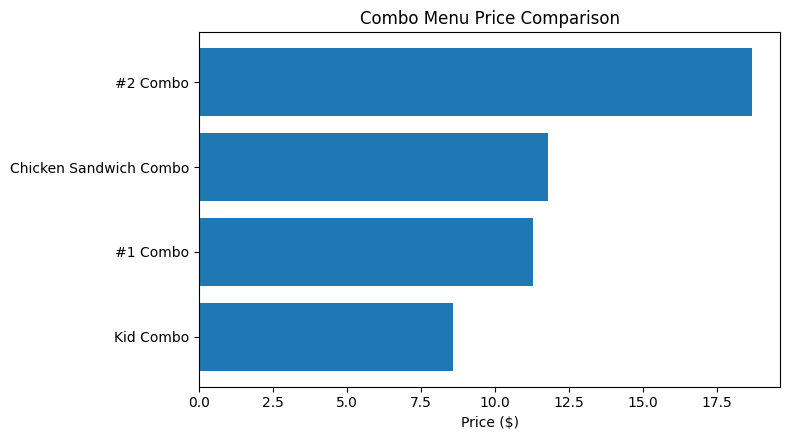

In [28]:
plt.figure(figsize=(8, 4.5))
plt.barh(menu_prices['combo_name'], menu_prices['price'])
plt.title('Combo Menu Price Comparison')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.savefig(CHART_DIR/'menu_price_comparison.png', dpi=150)
plt.show()

## 7. Supplier / Purchasing Price Comparison

The purchasing file contains supplier price columns such as US Food, Sysco, Costco, Restaurant Depot, and Food Service Direct. This section identifies the lowest visible supplier price per item when comparable supplier price data exists.

In [29]:
purchase_path = find_file('材料采购')
purchase_raw = pd.read_excel(purchase_path, sheet_name='use everyweek_Table 1')
purchase_raw.head(12)

,种类,已购,确定商家,价格,数量,US Food,Sysco,金世界,SJ,Costco,Restaurant depot,Food service direct.com
0,面包(Klosterman BBQ sesame bread),NaN,US food,NaN,8 bags,36.74,NaN,NaN,NaN,NaN,NaN,68.95
1,Crinkle Fries,NaN,Costco,NaN,30lb,31.03,NaN,NaN,NaN,1.17,29.57,NaN
2,Tater toes,NaN,Costco,NaN,NaN,1.91,1.88,N/a,NaN,1.31,1.60,NaN
3,沙拉(cabbage coleslaw),NaN,Costco,NaN,NaN,1.18,2.28,NaN,NaN,0.80,N/a(no carrot),NaN
4,汉堡皮,NaN,Costco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,生菜,NaN,Costco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Spam,NaN,Costco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Kimchi,NaN,Costco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,小包番茄酱,NaN,Costco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,糖,NaN,Costco,NaN,NaN,NaN,NaN,29.90,NaN,17.49（25lb）,NaN,NaN


In [30]:
# Standardize purchasing sheet
purchase = purchase_raw.copy()
purchase.columns = [str(c).strip() for c in purchase.columns]

supplier_cols = [c for c in purchase.columns if c not in ['种类', '已购', '确定商家', '价格', '数量']]
for col in supplier_cols:
    purchase[col] = clean_currency_series(purchase[col])

purchase['best_supplier'] = purchase[supplier_cols].idxmin(axis=1, skipna=True)
purchase['lowest_supplier_price'] = purchase[supplier_cols].min(axis=1, skipna=True)
purchase['highest_supplier_price'] = purchase[supplier_cols].max(axis=1, skipna=True)
purchase['price_spread'] = purchase['highest_supplier_price'] - purchase['lowest_supplier_price']

supplier_comparison = purchase[['种类', '确定商家', '数量', 'best_supplier', 'lowest_supplier_price', 'highest_supplier_price', 'price_spread']].dropna(subset=['lowest_supplier_price'])
supplier_comparison.sort_values('price_spread', ascending=False).head(15)

/tmp/ipykernel_7275/3378521762.py:9: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  purchase['best_supplier'] = purchase[supplier_cols].idxmin(axis=1, skipna=True)


,种类,确定商家,数量,best_supplier,lowest_supplier_price,highest_supplier_price,price_spread
20,mayo,RD,4 gal,Costco,19.99,89.00,69.01
28,白胡椒,J,5lb,金世界,23.99,80.00,56.01
15,Spiral Fries,RD,30lb,Sysco,1.67,49.39,47.72
61,吸管,NaN,3000ct,Sysco,0.01,42.99,42.98
0,面包(Klosterman BBQ sesame bread),US food,8 bags,US Food,36.74,68.95,32.21
1,Crinkle Fries,Costco,30lb,Costco,1.17,31.03,29.86
29,玉米淀粉,J,50lb,Costco,4.99,34.00,29.01
55,Yellowmustard,NaN,500ct,Costco,9.99,32.05,22.06
67,手套,NaN,NaN,Costco,11.69,32.90,21.21
33,蒜粉,J,5lb,金世界,10.99,30.37,19.38


In [31]:
# Count how often each supplier is the lowest-priced option
best_supplier_counts = supplier_comparison['best_supplier'].value_counts().reset_index()
best_supplier_counts.columns = ['supplier', 'lowest_price_count']
best_supplier_counts

,supplier,lowest_price_count
0,Costco,16
1,金世界,16
2,US Food,5
3,Sysco,4
4,Restaurant depot,4
5,SJ,3


/tmp/ipykernel_7275/2979977610.py:7: UserWarning: Glyph 37329 (\N{CJK UNIFIED IDEOGRAPH-91D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7275/2979977610.py:7: UserWarning: Glyph 19990 (\N{CJK UNIFIED IDEOGRAPH-4E16}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7275/2979977610.py:7: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7275/2979977610.py:8: UserWarning: Glyph 37329 (\N{CJK UNIFIED IDEOGRAPH-91D1}) missing from font(s) DejaVu Sans.
  plt.savefig(CHART_DIR/'supplier_lowest_price_count.png', dpi=150)
/tmp/ipykernel_7275/2979977610.py:8: UserWarning: Glyph 19990 (\N{CJK UNIFIED IDEOGRAPH-4E16}) missing from font(s) DejaVu Sans.
  plt.savefig(CHART_DIR/'supplier_lowest_price_count.png', dpi=150)
/tmp/ipykernel_7275/2979977610.py:8: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  plt.savefig(CHART_DIR/'su

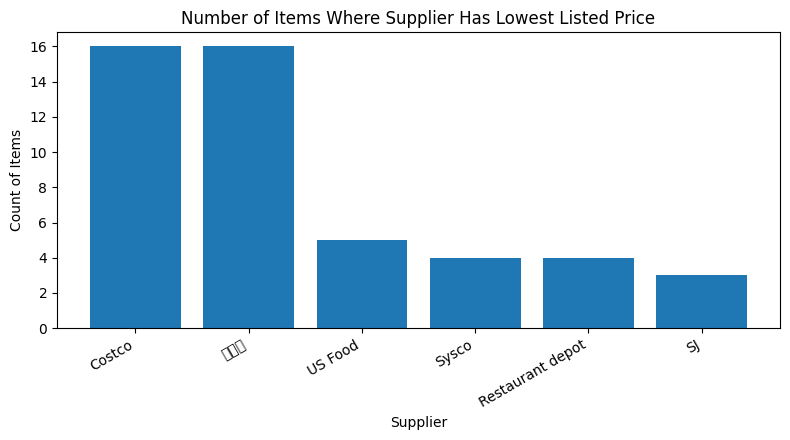

In [32]:
plt.figure(figsize=(8, 4.5))
plt.bar(best_supplier_counts['supplier'], best_supplier_counts['lowest_price_count'])
plt.title('Number of Items Where Supplier Has Lowest Listed Price')
plt.xlabel('Supplier')
plt.ylabel('Count of Items')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(CHART_DIR/'supplier_lowest_price_count.png', dpi=150)
plt.show()

## 8. Startup / Opening Expense Review

The opening-cost file tracks deposits, build-out, permits, supplies, equipment, and other early expenses. This section summarizes the largest visible expense rows.

In [33]:
startup_path = find_file('ChickenGoGO前')
startup_xl = pd.ExcelFile(startup_path)
startup_xl.sheet_names

['Chicken GoGo 前期_Tab', 'Chicken GoGo 前期_Tab_2', '开门流水']

In [34]:
startup_raw = pd.read_excel(startup_path, sheet_name='Chicken GoGo 前期_Tab')
startup_raw.head(12)

,Unnamed: 0,日期,存入,支出,JIng,Teng,Qiu,Total
0,第一期存入,2025-11-03 00:00:00,NaN,NaN,"13,888.88","16,666.66",14446+5000(cash),"50,001.54"
1,Tax预付款,5026-04-15 00:00:00,NaN,-900.00,NaN,NaN,NaN,"49,101.54"
2,DBA,NaN,NaN,NaN,NaN,-55（未结）,NaN,NaN
3,登报纸,NaN,NaN,NaN,NaN,-80（未结）,NaN,NaN
4,支票费用,2025-11-13 00:00:00,NaN,-90.72,NaN,NaN,NaN,"49,010.82"
5,信用卡押金,2025-11-17 00:00:00,NaN,"-1,000.00",NaN,NaN,NaN,"48,010.82"
6,Health Environment 图纸下来费用,2025-11-18 00:00:00,NaN,"-3,433.00",NaN,NaN,NaN,"44,577.82"
7,Building department,2025-12-04 00:00:00,NaN,"-5,490.37",NaN,NaN,NaN,"39,087.45"
8,房租及押金,2025-12-15 00:00:00,NaN,"-8,080.33",NaN,NaN,NaN,"31,007.12"
9,第二期存入,2026-01-15 00:00:00,NaN,NaN,"13,888.88","16,666.67",19446,"81,008.67"


In [35]:
startup = startup_raw.copy()
startup.columns = ['item', 'date', 'deposit', 'expense', 'jing', 'teng', 'qiu', 'running_total']
startup['expense_num'] = clean_currency_series(startup['expense'])
startup['deposit_num'] = clean_currency_series(startup['deposit'])
startup['running_total_num'] = clean_currency_series(startup['running_total'])
startup['date'] = pd.to_datetime(startup['date'], errors='coerce')

largest_expenses = startup.dropna(subset=['expense_num']).copy()
largest_expenses['expense_abs'] = largest_expenses['expense_num'].abs()
largest_expenses[['item', 'date', 'expense_num', 'running_total_num']].sort_values('expense_num').head(15)

,item,date,expense_num,running_total_num
10,装修款,2026-01-20,"-60,000.00","21,008.67"
21,装修款,2026-03-30,"-50,000.00","20,252.17"
25,装修款,2026-04-14,"-40,000.00","35,405.19"
22,设备钱,2026-04-06,"-36,246.97","-15,994.80"
13,装修款,2026-02-17,"-30,000.00","21,010.22"
12,装修款,2026-02-05,"-20,000.00","51,010.22"
16,Building department,2026-03-10,"-8,630.24","11,023.42"
24,Hood消防排气扇,2026-04-14,"-8,600.00","75,405.19"
8,房租及押金,2025-12-15,"-8,080.33","31,007.12"
26,画图费用Kevin,2026-04-16,"-7,000.00","28,405.19"


In [36]:
opening_cashflow = pd.read_excel(startup_path, sheet_name='开门流水', header=None)
opening_cashflow.columns = ['item', 'date', 'amount', 'running_balance', 'notes']
opening_cashflow['date'] = pd.to_datetime(opening_cashflow['date'], errors='coerce')
opening_cashflow['amount'] = pd.to_numeric(opening_cashflow['amount'], errors='coerce')
opening_cashflow['running_balance'] = pd.to_numeric(opening_cashflow['running_balance'], errors='coerce')
opening_cashflow_clean = opening_cashflow.dropna(subset=['item', 'amount'], how='any')
opening_cashflow_clean.sort_values('amount').head(12)

,item,date,amount,running_balance,notes
13,收银机器,2026-06-02,"-8,948.99","8,573.79",NaN
5,Pepsi公司,2026-05-21,"-1,117.20","20,136.49",NaN
12,员工第一次工资,2026-06-02,"-1,051.10","17,522.78",NaN
6,US food,2026-05-26,-799.26,"19,337.23",NaN
17,换硬币,2026-06-08,-515.00,"7,480.01",NaN
2,海报,2026-05-21,-480.71,"21,502.33",NaN
15,金世界,2026-06-05,-319.87,"8,274.12",NaN
16,Costco,2026-06-08,-279.11,"7,995.01",NaN
10,Pepsi公司,2026-05-28,-270.01,"18,649.04",NaN
29,Restaurant depot,2026-05-21,-246.65,"9,370.09",NaN


## Manager-Ready KPI Summary

This section brings the main operational metrics into one table. A data analyst intern should make it easy for the owner or manager to understand the business without reading every code cell.

In [37]:
# Create a one-page KPI summary table
available_labor_eff = labor_efficiency['sales_per_labor_hour'].dropna()

manager_kpis = pd.DataFrame({
    'KPI': [
        'Total Sales',
        'Average Daily Sales',
        'Total Tips',
        'Average Tip Rate',
        'Credit Card Share',
        'Cash Share',
        'Total Clocked Labor Hours',
        'Average Daily Labor Hours',
        'Average Sales per Labor Hour'
    ],
    'Value': [
        f"${sales['total_sales'].sum():,.2f}",
        f"${sales['total_sales'].mean():,.2f}",
        f"${sales['tips'].sum():,.2f}",
        f"{sales['tip_rate'].mean():.1%}",
        f"{card_share:.1%}",
        f"{cash_share:.1%}",
        f"{clock['elapsed_hours'].sum():,.2f}",
        f"{daily_labor['total_labor_hours'].mean():,.2f}",
        f"${available_labor_eff.mean():,.2f}" if len(available_labor_eff) > 0 else 'Not available because dates do not overlap'
    ],
    'Why It Matters': [
        'Shows overall revenue captured in the accounting file.',
        'Useful for basic staffing and purchasing planning.',
        'Helps understand employee tip pool and customer tipping behavior.',
        'Measures tips relative to sales volume.',
        'Shows reliance on card payments and possible card fee exposure.',
        'Shows cash-handling importance and cash reconciliation needs.',
        'Shows actual labor used from time clock records.',
        'Helps compare staffing level across business days.',
        'Connects labor use to revenue productivity.'
    ]
})
manager_kpis

,KPI,Value,Why It Matters
0,Total Sales,"$18,829.71",Shows overall revenue captured in the accounti...
1,Average Daily Sales,"$2,689.96",Useful for basic staffing and purchasing plann...
2,Total Tips,$870.78,Helps understand employee tip pool and custome...
3,Average Tip Rate,4.6%,Measures tips relative to sales volume.
4,Credit Card Share,86.3%,Shows reliance on card payments and possible c...
5,Cash Share,13.2%,Shows cash-handling importance and cash reconc...
6,Total Clocked Labor Hours,443.63,Shows actual labor used from time clock records.
7,Average Daily Labor Hours,15.88,Helps compare staffing level across business d...
8,Average Sales per Labor Hour,Not available because dates do not overlap,Connects labor use to revenue productivity.


## 9. Final Business Recommendations

These recommendations combine the sales, labor, payroll, purchasing, and menu analysis.

In [38]:
recommendations = []

recommendations.append({
    'Priority': 'High',
    'Area': 'Sales Tracking',
    'Finding': f"Average daily sales were ${sales['total_sales'].mean():,.2f} across {len(sales)} recorded days.",
    'Business Risk / Opportunity': 'Without consistent sales history, it is hard to forecast staffing, inventory, and cash needs.',
    'Recommended Action': 'Continue recording sales daily using the same columns and add item-level POS sales when available.',
    'Owner': 'Manager / Data Analyst Intern'
})
recommendations.append({
    'Priority': 'High',
    'Area': 'Labor Efficiency',
    'Finding': f"The time clock data contains {len(clock)} cleaned shift records and {clock['elapsed_hours'].sum():,.2f} total labor hours.",
    'Business Risk / Opportunity': 'Labor is one of the largest controllable restaurant costs.',
    'Recommended Action': 'Review sales per labor hour weekly and compare slow days against staffing levels.',
    'Owner': 'Manager / Scheduler'
})
recommendations.append({
    'Priority': 'Medium',
    'Area': 'Payment Mix',
    'Finding': f"Credit card payments represented about {card_share:.1%} of recorded sales.",
    'Business Risk / Opportunity': 'High card usage may create meaningful processing fees that reduce net profit.',
    'Recommended Action': 'Track card processing fees separately and compare gross sales vs. net deposits.',
    'Owner': 'Bookkeeper / Manager'
})
recommendations.append({
    'Priority': 'Medium',
    'Area': 'Scheduling Coverage',
    'Finding': 'Schedule data can be parsed by employee, role, day, start time, end time, and scheduled hours.',
    'Business Risk / Opportunity': 'Understaffing can slow service; overstaffing increases labor cost.',
    'Recommended Action': 'Build a weekly coverage view by 30-minute block and compare it with expected lunch/dinner rush periods.',
    'Owner': 'Scheduler'
})
recommendations.append({
    'Priority': 'Medium',
    'Area': 'Purchasing',
    'Finding': 'Supplier prices vary by item and vendor in the purchasing file.',
    'Business Risk / Opportunity': 'Buying every item from one vendor may miss cheaper item-level options.',
    'Recommended Action': 'Maintain a weekly supplier price tracker and choose suppliers item by item where quality is similar.',
    'Owner': 'Purchasing Lead'
})
recommendations.append({
    'Priority': 'Low',
    'Area': 'Menu Strategy',
    'Finding': f"Visible combo prices range from ${menu_prices['price'].min():.2f} to ${menu_prices['price'].max():.2f} in the menu file.",
    'Business Risk / Opportunity': 'Menu pricing cannot be fully optimized without item-level sales and food cost data.',
    'Recommended Action': 'Connect POS item sales with recipe/ingredient cost to calculate gross margin by menu item.',
    'Owner': 'Manager / Data Analyst Intern'
})

recommendations_df = pd.DataFrame(recommendations)
recommendations_df

,Priority,Area,Finding,Business Risk / Opportunity,Recommended Action,Owner
0,High,Sales Tracking,"Average daily sales were $2,689.96 across 7 re...","Without consistent sales history, it is hard t...",Continue recording sales daily using the same ...,Manager / Data Analyst Intern
1,High,Labor Efficiency,The time clock data contains 210 cleaned shift...,Labor is one of the largest controllable resta...,Review sales per labor hour weekly and compare...,Manager / Scheduler
2,Medium,Payment Mix,Credit card payments represented about 86.3% o...,High card usage may create meaningful processi...,Track card processing fees separately and comp...,Bookkeeper / Manager
3,Medium,Scheduling Coverage,"Schedule data can be parsed by employee, role,...",Understaffing can slow service; overstaffing i...,Build a weekly coverage view by 30-minute bloc...,Scheduler
4,Medium,Purchasing,Supplier prices vary by item and vendor in the...,Buying every item from one vendor may miss che...,Maintain a weekly supplier price tracker and c...,Purchasing Lead
5,Low,Menu Strategy,Visible combo prices range from $8.59 to $18.6...,Menu pricing cannot be fully optimized without...,Connect POS item sales with recipe/ingredient ...,Manager / Data Analyst Intern


## Limitations and Next Steps

A professional analyst should be honest about what the data can and cannot prove.

**Limitations**

- The sales file has daily totals, but not item-level POS transactions, so the notebook cannot yet identify best-selling menu items.
- The time clock and sales dates do not fully cover the same period, so labor-efficiency metrics are only available when dates overlap.
- Supplier comparison uses listed prices, but true purchasing decisions should also consider pack size, quality, delivery fees, minimum orders, and reliability.
- Menu prices were extracted from visible menu headers, not from a full POS database.
- Startup expense files are useful for tracking cash flow, but they may include manual notes that need owner verification.

**Recommended next data to collect**

1. POS item-level sales: item name, quantity, price, discount, order time, channel.
2. Ingredient recipe cost by menu item.
3. Waste/spoilage tracking.
4. Delivery app sales, fees, refunds, and ratings.
5. Customer wait time or order completion time.

With those extra datasets, the next version could calculate food cost percentage, gross margin by item, labor cost percentage, and promotion performance.

## 10. Export Cleaned Tables

This final section exports cleaned tables as CSV files so they can be reused in Excel, Tableau, Power BI, or future Jupyter notebooks.

In [39]:
EXPORT_DIR = Path('cleaned_outputs')
EXPORT_DIR.mkdir(exist_ok=True)

sales.to_csv(EXPORT_DIR/'cleaned_daily_sales.csv', index=False)
clock.to_csv(EXPORT_DIR/'cleaned_time_clock.csv', index=False)
payroll.to_csv(EXPORT_DIR/'cleaned_payroll.csv', index=False)
schedule.to_csv(EXPORT_DIR/'cleaned_schedule.csv', index=False)
menu_prices.to_csv(EXPORT_DIR/'cleaned_menu_prices.csv', index=False)
supplier_comparison.to_csv(EXPORT_DIR/'cleaned_supplier_comparison.csv', index=False)
recommendations_df.to_csv(EXPORT_DIR/'business_recommendations.csv', index=False)
manager_kpis.to_csv(EXPORT_DIR/'manager_kpi_summary.csv', index=False)
labor_efficiency.to_csv(EXPORT_DIR/'labor_efficiency.csv', index=False)

pd.DataFrame({'exported_file': sorted([p.name for p in EXPORT_DIR.glob('*.csv')])})

,exported_file
0,business_recommendations.csv
1,cleaned_daily_sales.csv
2,cleaned_menu_prices.csv
3,cleaned_payroll.csv
4,cleaned_schedule.csv
5,cleaned_supplier_comparison.csv
6,cleaned_time_clock.csv
7,labor_efficiency.csv
8,manager_kpi_summary.csv
